INFO:numexpr.utils:NumExpr defaulting to 12 threads.
/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


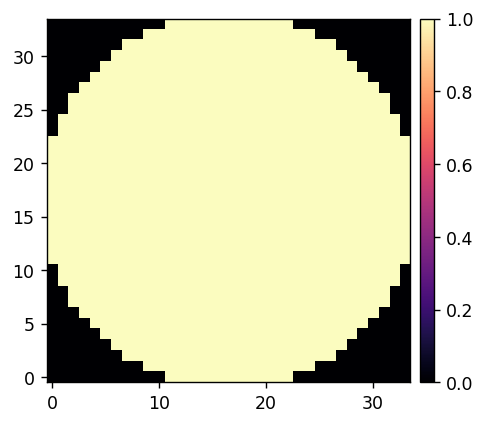

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 0.307

dm_mask = dm.create_mask(Nact=34, return_np=1)
utils.imshow([dm_mask])

In [3]:
campr_channel = 'campr'

# CAMPR_STREAM = ImageStream(campr_channel)
DM_STREAMT = ImageStream('dm00disp')
DM_STREAM00 = ImageStream('dm00disp00')
DM_STREAM01 = ImageStream('dm00disp01')
DM_STREAM02 = ImageStream('dm00disp02')
DM_STREAM03 = ImageStream('dm00disp03')
DM_STREAM04 = ImageStream('dm00disp04')
DM_STREAM05 = ImageStream('dm00disp05')

In [6]:
reload(coro_utils)

xc, yc = (5755, 2180)
ncamsci = 256
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

coro_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=campr_channel, bin_mode=4)
coro_utils.set_cam_exp_time(0.0001, client0, cam_name=campr_channel)
coro_utils.set_cam_gain(120, client0, cam_name=campr_channel)
coro_utils.set_cam_blacklevel(1.0, client0, cam_name=campr_channel)

Set campr ROI.
Set the campr exposure time to 1.00e-04s
Set the campr gain setting to 120.0
Set the campr blacklevel to 1.0


In [7]:
coro_utils.set_fiber_atten(17, client)

Set the fiber attenuation to 17.0


In [8]:
DM_STREAM00.write(-0.27 * np.ones((Nact,Nact)))

In [ ]:
# 0.065 um of astig-2

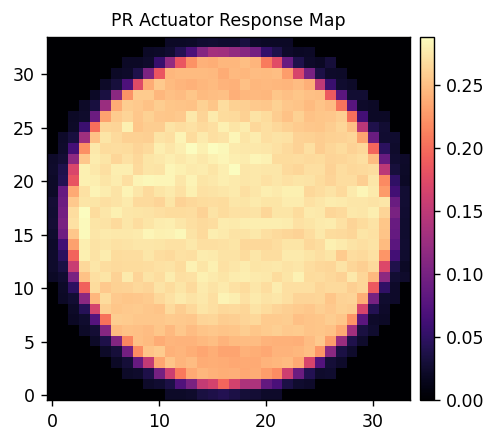

In [3]:
dmmap = fits.getdata('/opt/MagAOX/calib/fdpr2/kilo_dmdiv/dmmap.fits')
utils.imshow(
    [dmmap],
    titles=['PR Actuator Response Map']
)

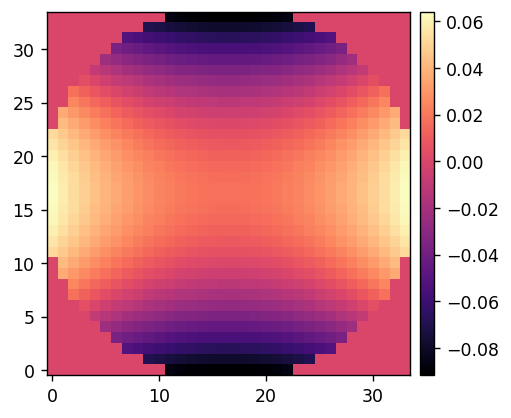

Saved data to:  dm_lo_correction.fits


In [50]:
dm_lo_correction = DM_STREAM01.grab_latest()
# defocus = -0.010
# astig2 = 0.035
utils.imshow([dm_lo_correction])
utils.save_fits('dm_lo_correction.fits', dm_lo_correction)

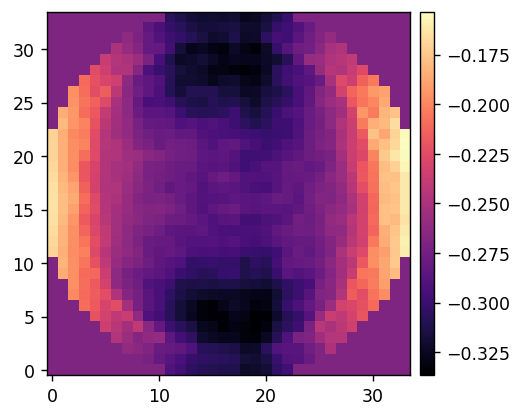

In [4]:
dm_flat = DM_STREAMT.grab_latest()
utils.imshow(
    [dm_flat]
)

In [16]:
utils.save_fits(f'dm_flat_{today}.fits', dm_flat)

Saved data to:  dm_flat_20260225.fits


In [32]:
DM_STREAM03.write(dm_flat)

In [14]:
DM_STREAM03.write(np.zeros_like(dm_mask))

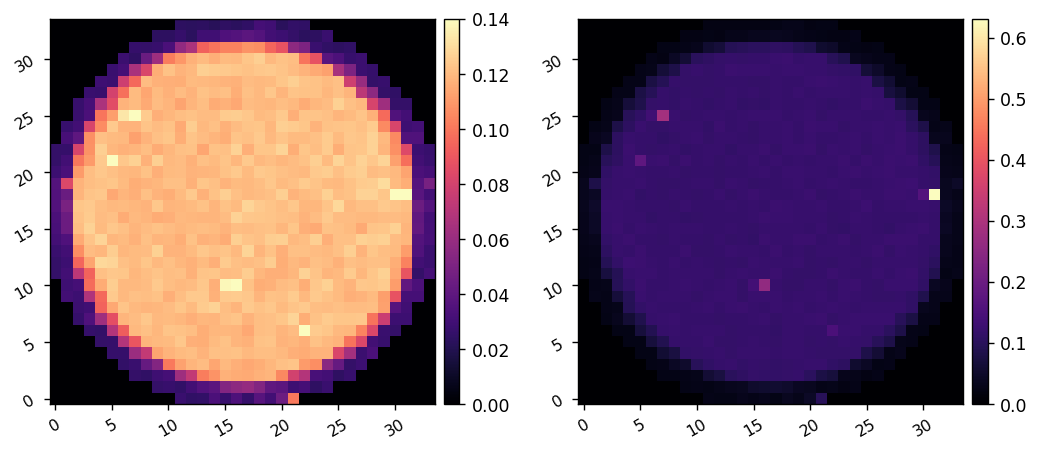

In [128]:
dmmap = fits.getdata('/opt/MagAOX/calib/fdpr2/kilo_dmdiv/dmmap.fits')
imshow2(dmmap, dmmap, vmax1=0.14)

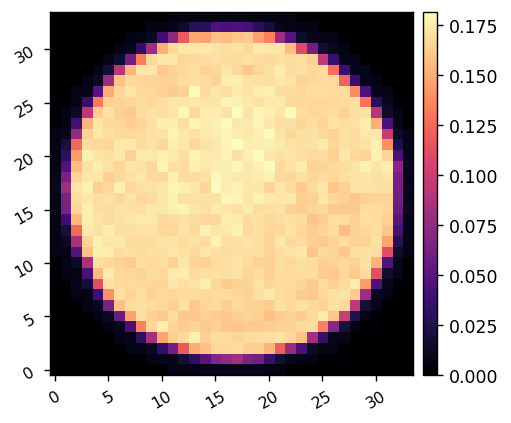

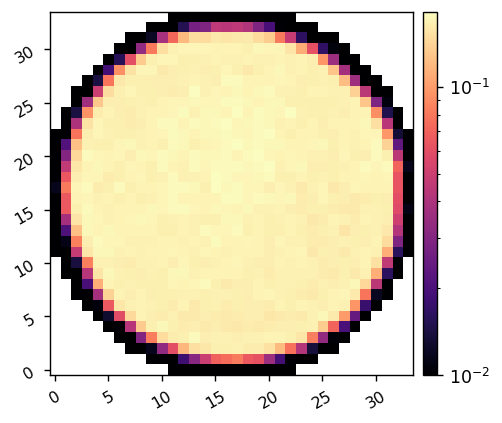

In [9]:
dmmap = fits.getdata('/opt/MagAOX/calib/fdpr2/kilo_dmdiv/dmmap.fits')
imshow1(dmmap)
imshow1(dmmap, lognorm=1, vmin=1e-2)